# 🌲 Random Forest vs. Bagged Decision Tree

**Dataset:** `unconv_MV_v5.csv`  
**Target:** `Prod` (MCFPD)  
**Features:** `Por` (Porosity %), `AI` (Acoustic Impedance)

A step-by-step comparison of three tree-based models to illustrate how ensemble methods reduce overfitting:

| Model | Strategy |
|---|---|
| Decision Tree | Single tree — high variance, overfits easily |
| Bagged Tree | Bootstrap aggregation of many trees — reduces variance |
| Random Forest | Bagging + random feature subsampling — further decorrelates trees |

---

## 📋 Table of Contents
1. [Imports & Setup](#1)
2. [Helper Functions](#2)
3. [Load & Explore Data](#3)
4. [Feature Selection & Correlation Analysis](#4)
5. [Train-Test Split & Distribution Check](#5)
6. [Baseline — Decision Tree (Overfitting)](#6)
7. [Ensemble 1 — Bagged Decision Tree](#7)
8. [Ensemble 2 — Random Forest](#8)
9. [Tuned Random Forest — GridSearchCV](#9)
10. [Model Comparison](#10)
11. [Key Findings](#11)

---
## 1. Imports & Setup <a id='1'></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FuncFormatter
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from IPython.display import display, HTML

RANDOM_STATE = 72
np.random.seed(RANDOM_STATE)

---
## 2. Helper Functions <a id='2'></a>

All utility functions are defined upfront. `feature_rank_plot` and `plot_corr` are adapted from Prof. Michael Pyrcz (GeostatsGuy).

In [8]:
def comma_format(x, pos):
    return f'{int(x):,}'


def add_grid():
    """Add major and minor gridlines to the current axes."""
    plt.gca().grid(True, which='major', linewidth=1.0)
    plt.gca().grid(True, which='minor', linewidth=0.2)
    plt.gca().tick_params(which='major', length=7)
    plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
    plt.gca().yaxis.set_minor_locator(AutoMinorLocator())


def display_sidebyside(*args):
    """Render multiple DataFrames side by side in a Jupyter cell."""
    html_str = ''.join(df.head().to_html() for df in args)
    display(HTML(f'<div style="display:flex;gap:20px">{html_str}</div>'))


def fit_and_evaluate(model, X_train, y_train, X_test, y_test):
    """
    Fit a regression model and return performance metrics for train and test sets.

    Parameters
    ----------
    model    : sklearn estimator (unfitted)
    X_train, y_train : training data
    X_test,  y_test  : testing data

    Returns
    -------
    metrics_dict  : dict  — MSE, MAE, R² for train and test
    y_test_pred   : array — test predictions
    y_train_pred  : array — train predictions
    """
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    metrics_dict = {
        'MSE Train': mean_squared_error(y_train, y_train_pred),
        'MSE Test':  mean_squared_error(y_test,  y_test_pred),
        'MAE Train': mean_absolute_error(y_train, y_train_pred),
        'MAE Test':  mean_absolute_error(y_test,  y_test_pred),
        'R² Train':  r2_score(y_train, y_train_pred),
        'R² Test':   r2_score(y_test,  y_test_pred),
    }
    return metrics_dict, y_test_pred, y_train_pred


def plot_actual_vs_predicted(y_test_pred, y_train_pred, y_train, y_test, title):
    """
    Scatter plot of actual vs. predicted values for train and test sets
    with a 1:1 perfect prediction reference line.
    """
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test,  y_test_pred,  c='blue', marker='o', alpha=0.7, edgecolors='black', s=15, label='Test')
    plt.scatter(y_train, y_train_pred, c='red',  marker='s', alpha=0.5, edgecolors='black', s=15, label='Train')

    vmin = min(y_train.min(), y_test.min())
    vmax = max(y_train.max(), y_test.max())
    plt.plot([vmin, vmax], [vmin, vmax], 'k--', lw=1.5, label='Perfect Prediction')

    plt.xlabel('Actual Production (MCFPD)')
    plt.ylabel('Predicted Production (MCFPD)')
    plt.title(title, fontweight='bold'); plt.legend(); add_grid()
    plt.tight_layout(); plt.show()


def feature_rank_plot(pred, metric, mmin, mmax, nominal, title, ylabel, mask):
    mpred = len(pred)
    mask_low  = nominal - mask * (nominal - mmin)
    mask_high = nominal + mask * (mmax - nominal)
    m = mpred + 1
    plt.plot(pred, metric, color='black', zorder=20)
    plt.scatter(pred, metric, marker='o', s=10, color='black', zorder=100)
    plt.plot([-0.5, m - 1.5], [0.0, 0.0], 'r--', linewidth=1.0, zorder=1)
    plt.fill_between(np.arange(0, mpred), np.zeros(mpred), metric,
                     where=(metric < nominal), interpolate=True, color='dodgerblue', alpha=0.3)
    plt.fill_between(np.arange(0, mpred), np.zeros(mpred), metric,
                     where=(metric > nominal), interpolate=True, color='lightcoral', alpha=0.3)
    plt.fill_between(np.arange(0, mpred), np.full(mpred, mask_low), metric,
                     where=(metric < mask_low), interpolate=True, color='blue', alpha=0.8, zorder=10)
    plt.fill_between(np.arange(0, mpred), np.full(mpred, mask_high), metric,
                     where=(metric > mask_high), interpolate=True, color='red', alpha=0.8, zorder=10)
    plt.xlabel('Predictor Features'); plt.ylabel(ylabel); plt.title(title)
    plt.ylim(mmin, mmax); plt.xlim([-0.5, m - 1.5]); add_grid()


def plot_corr(corr_matrix, title, limits, mask):
    my_colormap = plt.get_cmap('RdBu_r', 256)
    newcolors   = my_colormap(np.linspace(0, 1, 256))
    white       = np.array([1, 1, 1, 1])
    wl = int(128 - mask * 128); wh = int(128 + mask * 128)
    newcolors[wl:wh, :] = white
    newcmp = ListedColormap(newcolors)
    m  = corr_matrix.shape[0]
    im = plt.matshow(corr_matrix, fignum=0, vmin=-limits, vmax=limits, cmap=newcmp)
    plt.xticks(range(m), corr_matrix.columns)
    ax = plt.gca(); ax.xaxis.set_label_position('bottom'); ax.xaxis.tick_bottom()
    plt.yticks(range(m), corr_matrix.columns)
    plt.colorbar(im, orientation='vertical'); plt.title(title)
    for i in range(m):
        plt.plot([i-0.5, i-0.5], [-0.5, m-0.5], color='black')
        plt.plot([-0.5, m-0.5], [i-0.5, i-0.5], color='black')
    plt.ylim([-0.5, m-0.5]); plt.xlim([-0.5, m-0.5])

---
## 3. Load & Explore Data <a id='3'></a>

In [9]:
data = pd.read_csv(
    'https://raw.githubusercontent.com/Shontu72/python_data-science-learning__-/main/DATA/unconv_MV_v5.csv'
)
print(f'Shape: {data.shape}')
data.info()

Shape: (200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Well     200 non-null    int64  
 1   Por      200 non-null    float64
 2   Perm     200 non-null    float64
 3   AI       200 non-null    float64
 4   Brittle  200 non-null    float64
 5   TOC      200 non-null    float64
 6   VR       200 non-null    float64
 7   Prod     200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


In [10]:
data.describe().transpose()[['count', 'mean', 'std', 'min', 'max']]

,count,mean,std,min,max
Well,200.0,100.500000,57.879185,1.000000,200.000000
Por,200.0,14.991150,2.971176,6.550000,23.550000
Perm,200.0,4.330750,1.731014,1.130000,9.870000
AI,200.0,2.968850,0.566885,1.280000,4.630000
Brittle,200.0,48.161950,14.129455,10.940000,84.330000
TOC,200.0,0.990450,0.481588,-0.190000,2.180000
VR,200.0,1.964300,0.300827,0.930000,2.870000
Prod,200.0,4311.219852,992.038414,2107.139414,6662.622385


---
## 4. Feature Selection & Correlation Analysis <a id='4'></a>

`Por` is selected as the primary feature due to its high correlation with production. `AI` (Acoustic Impedance) is selected as the secondary feature — it provides the second-highest independent signal after accounting for the collinearity between Por, Perm, and TOC.

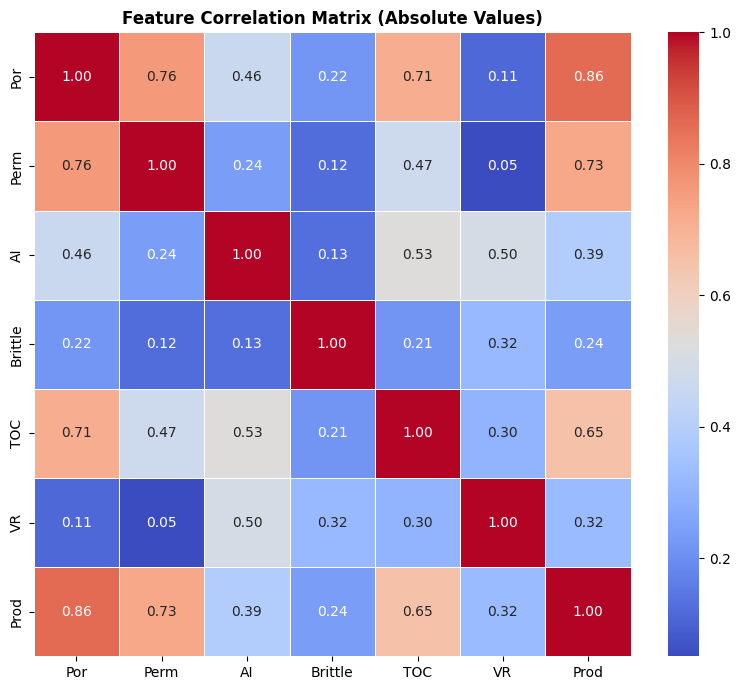

In [11]:
# Full correlation heatmap to justify feature selection
features_for_corr = data.drop(columns=['Well'])
corr_full = features_for_corr.corr().abs()

plt.figure(figsize=(8, 7))
sns.heatmap(corr_full, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix (Absolute Values)', fontweight='bold')
plt.tight_layout(); plt.show()

In [12]:
# Feature and target setup
x_name = ['Por', 'AI']
y_name = 'Prod'

X = data[x_name]
y = data[y_name]

df = pd.concat([X, y], axis=1)

# Axis ranges (from data.describe())
x_min = [0, 0]; x_max = [30, 5]
y_min = 2000;   y_max = 6700

x_labels    = ['Porosity', 'Acoustic Impedance']
y_label     = 'Production'
x_units     = ['%', 'Pa·s/m']
y_unit      = 'MCFPD'
x_labelunits = [f'{x_labels[i]} ({x_units[i]})' for i in range(len(x_name))]
y_labelunit  = f'{y_label} ({y_unit})'

print('Selected features:', x_name)
print('Target:', y_name)
df.describe().transpose()[['count', 'mean', 'std', 'min', 'max']]

Selected features: ['Por', 'AI']
Target: Prod


,count,mean,std,min,max
Por,200.0,14.991150,2.971176,6.550000,23.550000
AI,200.0,2.968850,0.566885,1.280000,4.630000
Prod,200.0,4311.219852,992.038414,2107.139414,6662.622385


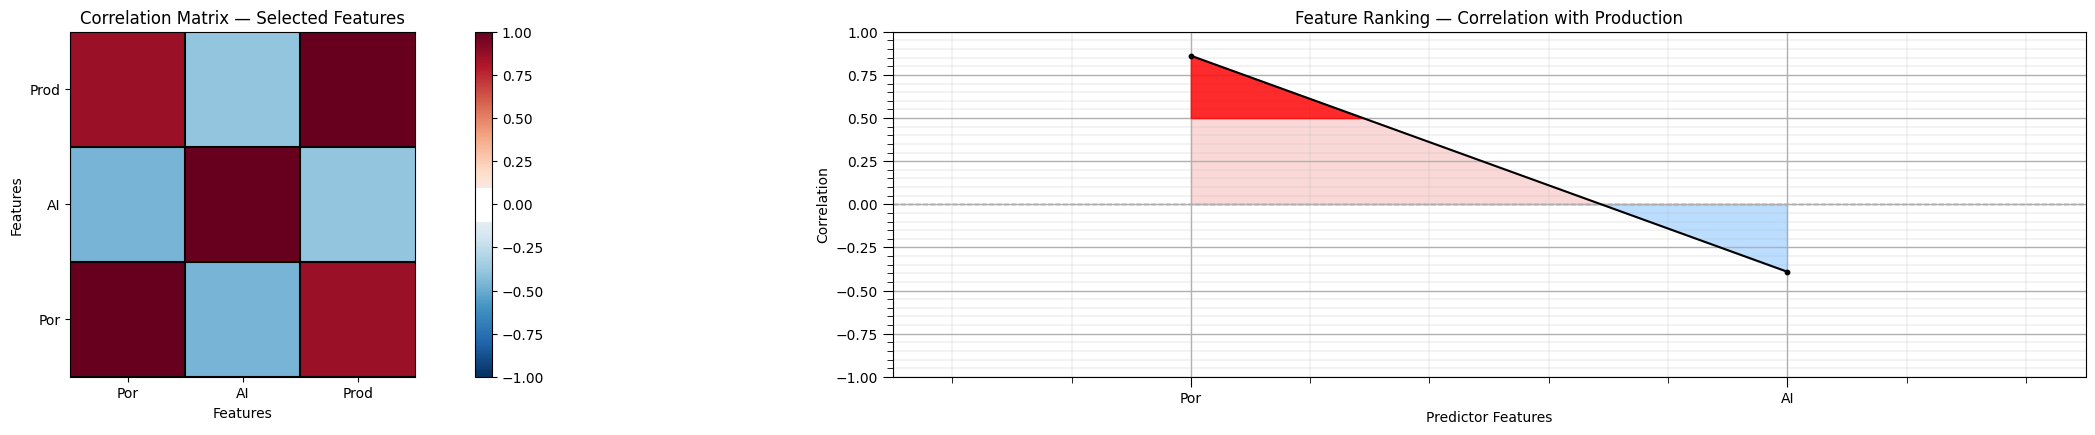

In [13]:
# Correlation matrix and feature ranking for selected features
corr_matrix = df.corr()
correlation  = corr_matrix.iloc[:, -1].values[:-1]

fig = plt.figure(figsize=(14, 5))
plt.subplot(121)
plot_corr(corr_matrix, 'Correlation Matrix — Selected Features', 1.0, 0.1)
plt.xlabel('Features'); plt.ylabel('Features')

plt.subplot(122)
feature_rank_plot(x_name, correlation, -1.0, 1.0, 0.0,
                  f'Feature Ranking — Correlation with {y_label}', 'Correlation', 0.5)
plt.subplots_adjust(right=2.0, top=0.8, wspace=0.2)
plt.show()

---
## 5. Train-Test Split & Distribution Check <a id='5'></a>

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

df_train = pd.concat([X_train, y_train], axis=1)
df_test  = pd.concat([X_test,  y_test],  axis=1)
display_sidebyside(df_train, df_test)

Train: 160 | Test: 40


,Por,AI,Prod
18,14.73,3.03,4534.585915
62,18.21,3.34,5620.911404
73,16.62,2.31,4087.529805
107,17.17,2.35,4733.965648
198,15.55,2.48,5087.592149
,Por,AI,Prod
177,11.80,3.64,2819.977847
43,11.09,3.16,2677.297348
182,9.88,3.64,3141.540928
169,11.71,4.01,2940.975811


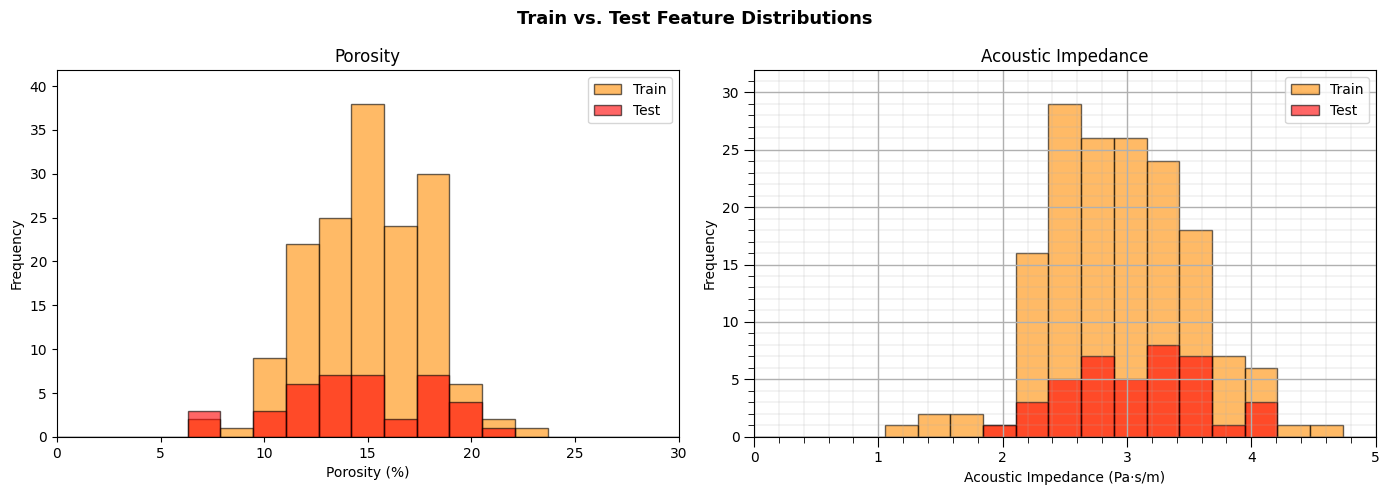

In [15]:
# Histograms — verify similar train/test distributions
nbins = 20
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, ax in enumerate(axes):
    f1, _, _ = ax.hist(df_train[x_name[i]],
                       bins=np.linspace(x_min[i], x_max[i], nbins),
                       alpha=0.6, edgecolor='black', color='darkorange', label='Train')
    f2, _, _ = ax.hist(df_test[x_name[i]],
                       bins=np.linspace(x_min[i], x_max[i], nbins),
                       alpha=0.6, edgecolor='black', color='red', label='Test')
    ax.set_xlabel(x_labelunits[i]); ax.set_ylabel('Frequency')
    ax.set_title(x_labels[i]); ax.set_xlim([x_min[i], x_max[i]])
    ax.set_ylim([0, max(f1.max(), f2.max()) * 1.1])
    add_grid(); ax.legend(loc='upper right')

plt.suptitle('Train vs. Test Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. Baseline — Decision Tree (Overfitting) <a id='6'></a>

A single, unconstrained decision tree is used as the baseline. It typically overfits — achieving near-perfect training R² but poor test R².

In [16]:
dt_model = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_metrics, y_test_pred_dt, y_train_pred_dt = fit_and_evaluate(
    dt_model, X_train, y_train, X_test, y_test
)

print('Decision Tree Metrics:')
for k, v in dt_metrics.items():
    print(f'  {k}: {v:,.3f}')
print()
print(f'  Train-Test R² gap: {dt_metrics["R² Train"] - dt_metrics["R² Test"]:.3f}  ← overfitting indicator')

Decision Tree Metrics:
  MSE Train: 0.000
  MSE Test: 516,309.530
  MAE Train: 0.000
  MAE Test: 518.416
  R² Train: 1.000
  R² Test: 0.636

  Train-Test R² gap: 0.364  ← overfitting indicator


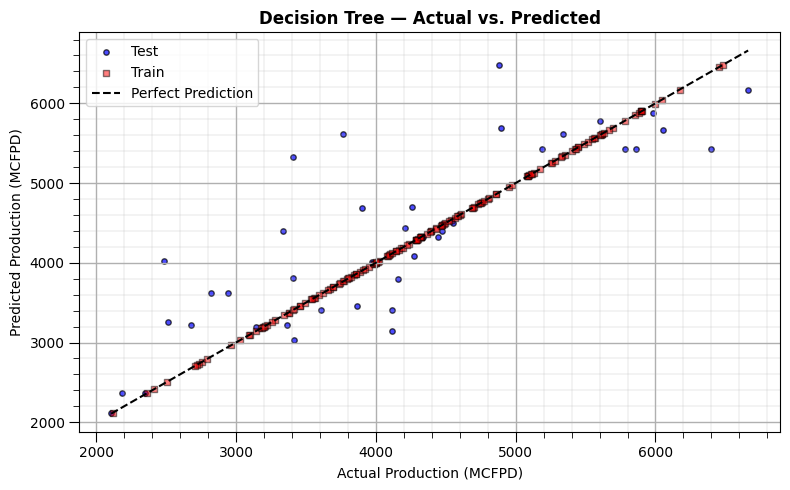

In [17]:
plot_actual_vs_predicted(y_test_pred_dt, y_train_pred_dt, y_train, y_test,
                         'Decision Tree — Actual vs. Predicted')

> ⚠️ **Overfitting:** The large gap between Train R² (~1.0) and Test R² confirms the decision tree has memorised the training data rather than learning generalizable patterns.

---
## 7. Ensemble 1 — Bagged Decision Tree <a id='7'></a>

Bagging (Bootstrap Aggregation) trains many trees on random data subsamples and averages their predictions. This reduces variance without changing individual tree bias.

In [18]:
from sklearn import tree as sk_tree

bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    n_estimators=200,
    random_state=RANDOM_STATE
)
bag_metrics, y_test_pred_bag, y_train_pred_bag = fit_and_evaluate(
    bag_model, X_train, y_train, X_test, y_test
)

print('Bagged Tree Metrics:')
for k, v in bag_metrics.items():
    print(f'  {k}: {v:,.3f}')
print()
print(f'  Train-Test R² gap: {bag_metrics["R² Train"] - bag_metrics["R² Test"]:.3f}')

Bagged Tree Metrics:
  MSE Train: 42,388.643
  MSE Test: 461,118.673
  MAE Train: 162.354
  MAE Test: 478.919
  R² Train: 0.951
  R² Test: 0.675

  Train-Test R² gap: 0.276


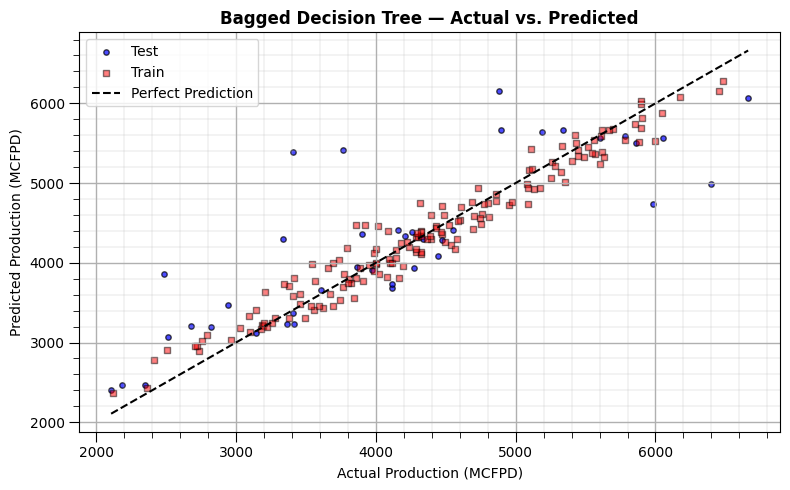

In [19]:
plot_actual_vs_predicted(y_test_pred_bag, y_train_pred_bag, y_train, y_test,
                         'Bagged Decision Tree — Actual vs. Predicted')

---
## 8. Ensemble 2 — Random Forest <a id='8'></a>

Random Forest extends bagging by also randomising the **feature subset** considered at each split (`max_features='sqrt'`). This decorrelates individual trees, further reducing variance compared to bagging alone.

In [20]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_features='sqrt',    # Only consider sqrt(n_features) at each split
    random_state=RANDOM_STATE
)
rf_metrics, y_test_pred_rf, y_train_pred_rf = fit_and_evaluate(
    rf_model, X_train, y_train, X_test, y_test
)

print('Random Forest Metrics:')
for k, v in rf_metrics.items():
    print(f'  {k}: {v:,.3f}')
print()
print(f'  Train-Test R² gap: {rf_metrics["R² Train"] - rf_metrics["R² Test"]:.3f}')

Random Forest Metrics:
  MSE Train: 42,648.234
  MSE Test: 476,309.133
  MAE Train: 165.985
  MAE Test: 509.490
  R² Train: 0.950
  R² Test: 0.664

  Train-Test R² gap: 0.287


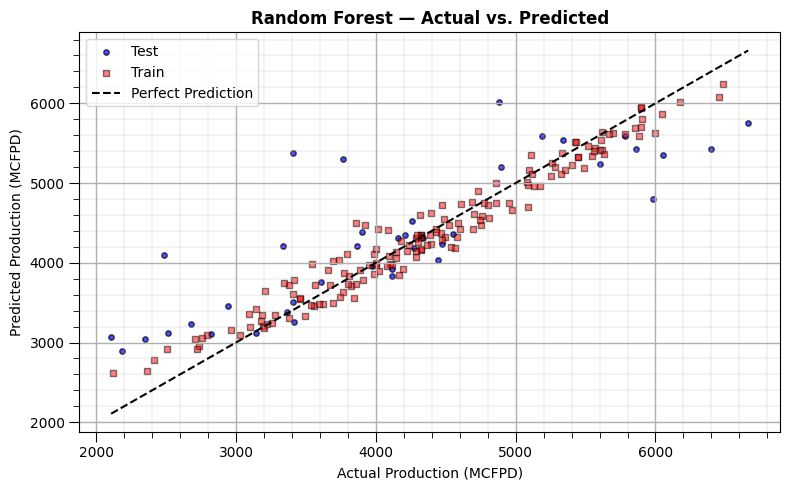

In [21]:
plot_actual_vs_predicted(y_test_pred_rf, y_train_pred_rf, y_train, y_test,
                         'Random Forest — Actual vs. Predicted')

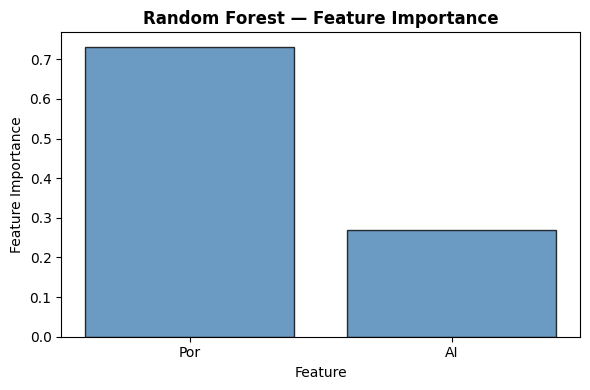

  Por: 0.732
  AI: 0.268


In [22]:
# Feature importance — which feature drives the most splits?
importances = rf_model.feature_importances_
indices     = np.argsort(importances)[::-1]

plt.figure(figsize=(6, 4))
plt.bar(range(len(x_name)), importances[indices], edgecolor='black', color='steelblue', alpha=0.8)
plt.xticks(range(len(x_name)), np.array(x_name)[indices])
plt.xlabel('Feature'); plt.ylabel('Feature Importance')
plt.title('Random Forest — Feature Importance', fontweight='bold')
plt.tight_layout(); plt.show()

for i in indices:
    print(f'  {x_name[i]}: {importances[i]:.3f}')

> **Note:** With only 2 features and `max_features='sqrt'` = 1, the forest randomly selects 1 feature per split — meaning each tree sees the same single-feature subsets as bagging. The improvement from bagging to Random Forest is therefore limited on this 2-feature dataset. With more features, the gap would be more pronounced.

---
## 9. Tuned Random Forest — GridSearchCV <a id='9'></a>

We tune `n_estimators`, `max_features`, `max_depth`, and `min_samples_leaf` simultaneously using 5-fold cross-validation.

In [23]:
param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_features':    [1, 2, 'log2'],
    'max_depth':       [None, 2, 4, 6],
    'min_samples_leaf': [1, 2, 5, 10]
}

rf_base   = RandomForestRegressor(random_state=RANDOM_STATE)
rf_search = GridSearchCV(rf_base, param_grid, cv=5, scoring='r2', n_jobs=-1)
rf_search.fit(X_train, y_train)

print('Best hyperparameters:')
print(rf_search.best_params_)

Best hyperparameters:
{'max_depth': 4, 'max_features': 2, 'min_samples_leaf': 10, 'n_estimators': 200}


In [24]:
best_rf = rf_search.best_estimator_
best_rf_metrics, y_test_pred_best, y_train_pred_best = fit_and_evaluate(
    best_rf, X_train, y_train, X_test, y_test
)

print('Tuned Random Forest Metrics:')
for k, v in best_rf_metrics.items():
    print(f'  {k}: {v:,.3f}')
print()
print(f'  Train-Test R² gap: {best_rf_metrics["R² Train"] - best_rf_metrics["R² Test"]:.3f}')

Tuned Random Forest Metrics:
  MSE Train: 205,131.028
  MSE Test: 356,563.837
  MAE Train: 356.505
  MAE Test: 461.678
  R² Train: 0.761
  R² Test: 0.748

  Train-Test R² gap: 0.013


---
## 10. Model Comparison <a id='10'></a>

In [25]:
result_df = pd.DataFrame([dt_metrics, bag_metrics, rf_metrics, best_rf_metrics],
                         index=['Decision Tree', 'Bagged Tree',
                                'Random Forest', 'Tuned Random Forest'])
result_df = result_df.round(4)
result_df['R² Gap (overfit)'] = (result_df['R² Train'] - result_df['R² Test']).round(4)
result_df

,MSE Train,MSE Test,MAE Train,MAE Test,R² Train,R² Test,R² Gap (overfit)
Decision Tree,0.0000,516309.5300,0.0000,518.4162,1.0000,0.6355,0.3645
Bagged Tree,42388.6427,461118.6732,162.3544,478.9191,0.9506,0.6745,0.2761
Random Forest,42648.2337,476309.1335,165.9845,509.4899,0.9503,0.6638,0.2865
Tuned Random Forest,205131.0284,356563.8368,356.5053,461.6779,0.7611,0.7483,0.0128


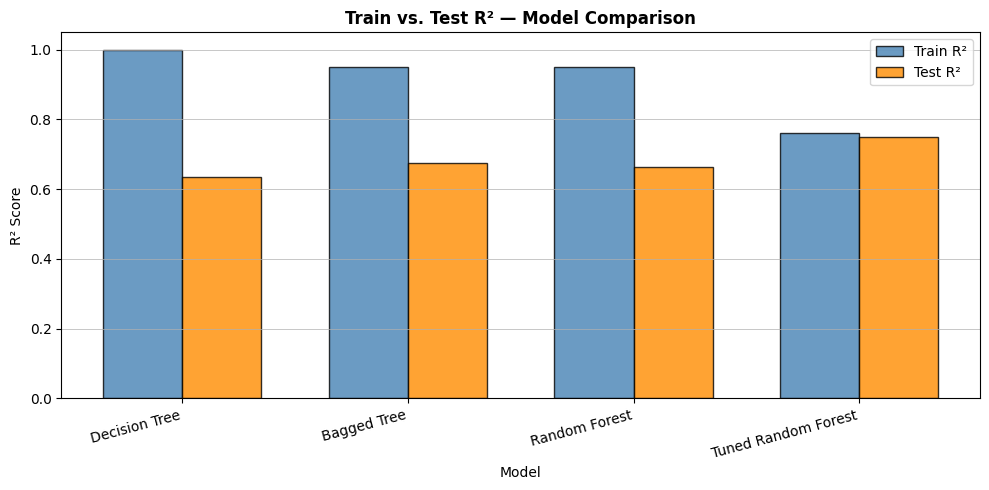

In [26]:
# Bar chart — R² train vs. test for all models
models  = result_df.index.tolist()
r2_train = result_df['R² Train'].values
r2_test  = result_df['R² Test'].values

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, r2_train, width, label='Train R²', color='steelblue', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, r2_test,  width, label='Test R²',  color='darkorange', edgecolor='black', alpha=0.8)

ax.set_xlabel('Model'); ax.set_ylabel('R² Score')
ax.set_title('Train vs. Test R² — Model Comparison', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylim([0, 1.05]); ax.legend(); ax.grid(axis='y', linewidth=0.5)
plt.tight_layout(); plt.show()

---
## 11. Key Findings <a id='11'></a>

| # | Finding | Detail |
|---|---|---|
| 1 | **Decision Tree overfits severely** | Train R²≈1.0, large train-test gap — memorises training noise |
| 2 | **Bagging reduces variance** | Averaging 200 bootstrap trees substantially closes the train-test R² gap |
| 3 | **Random Forest offers marginal gain on 2 features** | With only 2 features, `max_features='sqrt'`=1 provides limited additional decorrelation over bagging |
| 4 | **Tuning matters** | GridSearchCV improves test R² further by constraining tree depth and leaf size |
| 5 | **Porosity dominates** | Feature importance shows Por drives a majority of splits across all ensemble models |
| 6 | **More features → bigger RF advantage** | On higher-dimensional datasets, Random Forest's feature randomness would create a larger gap over bagging |

---